# Plot LFP model firing rates

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *
import population_utils as pu



2025-09-24 17:47:26.132915: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-24 17:47:26.142206: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-24 17:47:26.153253: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-24 17:47:26.156589: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-24 17:47:26.164790: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 400
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [ ]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

theta4_dirs = [m for m in model_dirs if '4.0' in m] # 4Hz models only
theta8_dirs = [m for m in model_dirs if '8.0' in m] # 8Hz models only

In [4]:
# choose a model to visualize for now
model_name = theta4_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhv_dict_delay400.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhv_dict_delay400_lfp_inh0.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/neural_dict_delay400_lfp_inh0.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhv_dict_delay400_lfp_exc0.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/neural_dict_delay400_stimon100.pkl', '/home/nuttidalab/Documents/renee/lfp_input_mo

## plot LFP, spikes & rates

In [5]:
# neural data
lfp_data, spikes_data, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=True, load_spikes=True, load_rates=True,
                                                  all_models_dir=all_models_dir)

### spikes

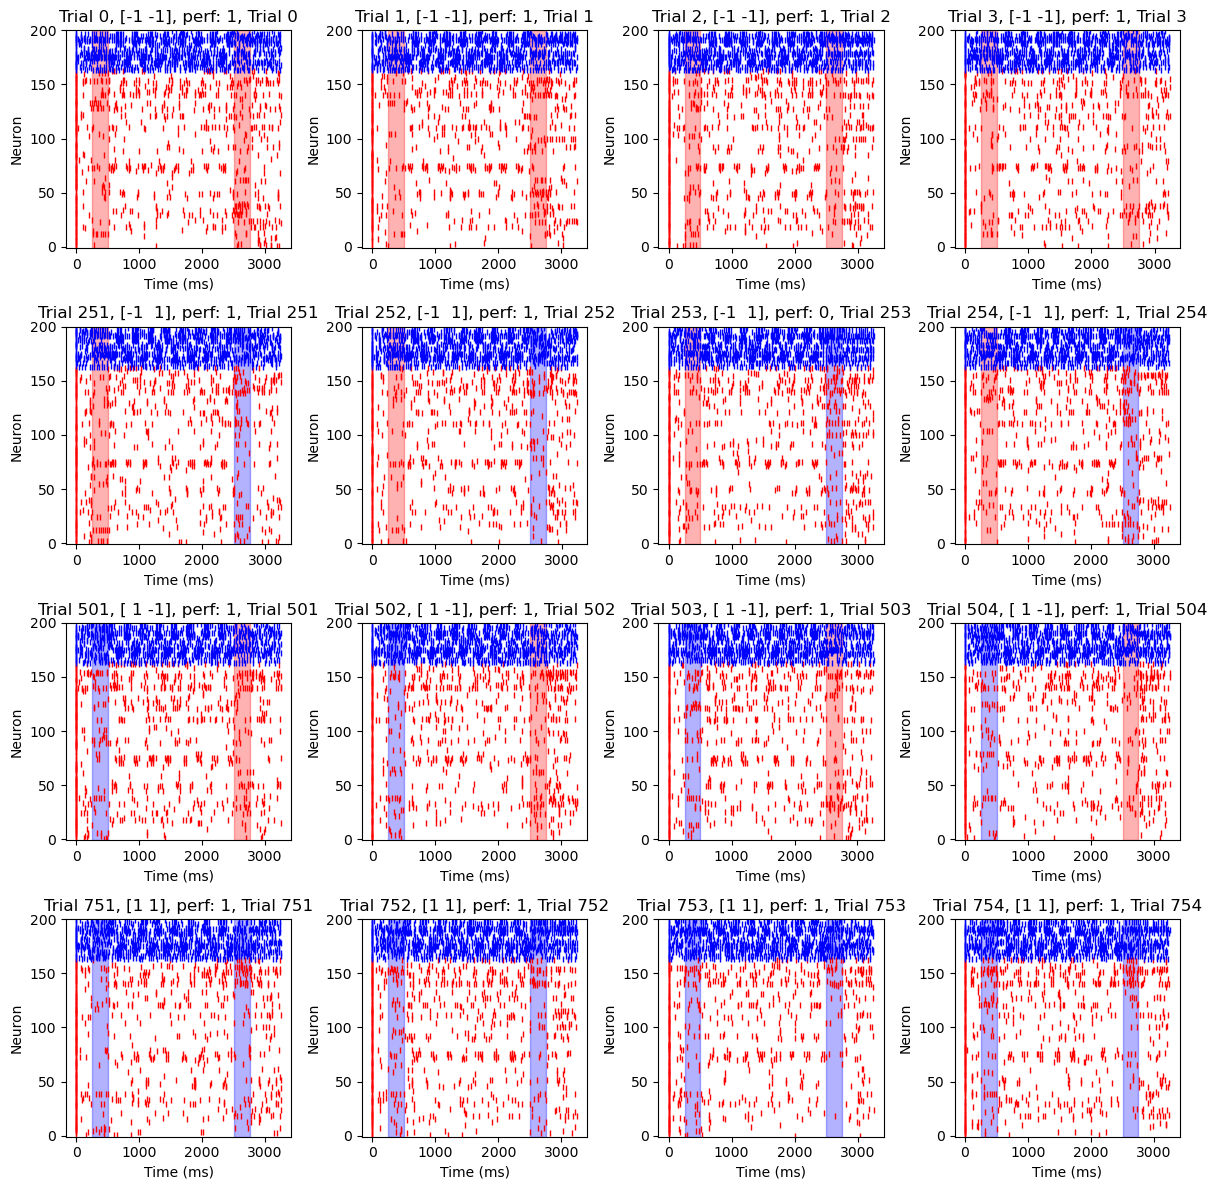

In [10]:
# plot 16 random trials, sort using the sort from the first trial (-1/-1)

importlib.reload(sn)

trial_ids = [0, 1, 2, 3, 251, 252, 253, 254, 501, 502, 503, 504, 751, 752, 753, 754]
fig, ax = plt.subplots(4, 4, figsize=(12, 12))


for i, trial_id in enumerate(trial_ids):
    trial_df = spikes_data[spikes_data['trial_id'] == trial_id]
    
    ax_i = np.unravel_index(i, (4, 4))
    sn.plot_trial_raster(trial_df, condn_phrase, condn_num, ax=ax[ax_i], title=f'Trial {trial_id}', all_models_dir=all_models_dir)
plt.tight_layout()
plt.show()

### rates

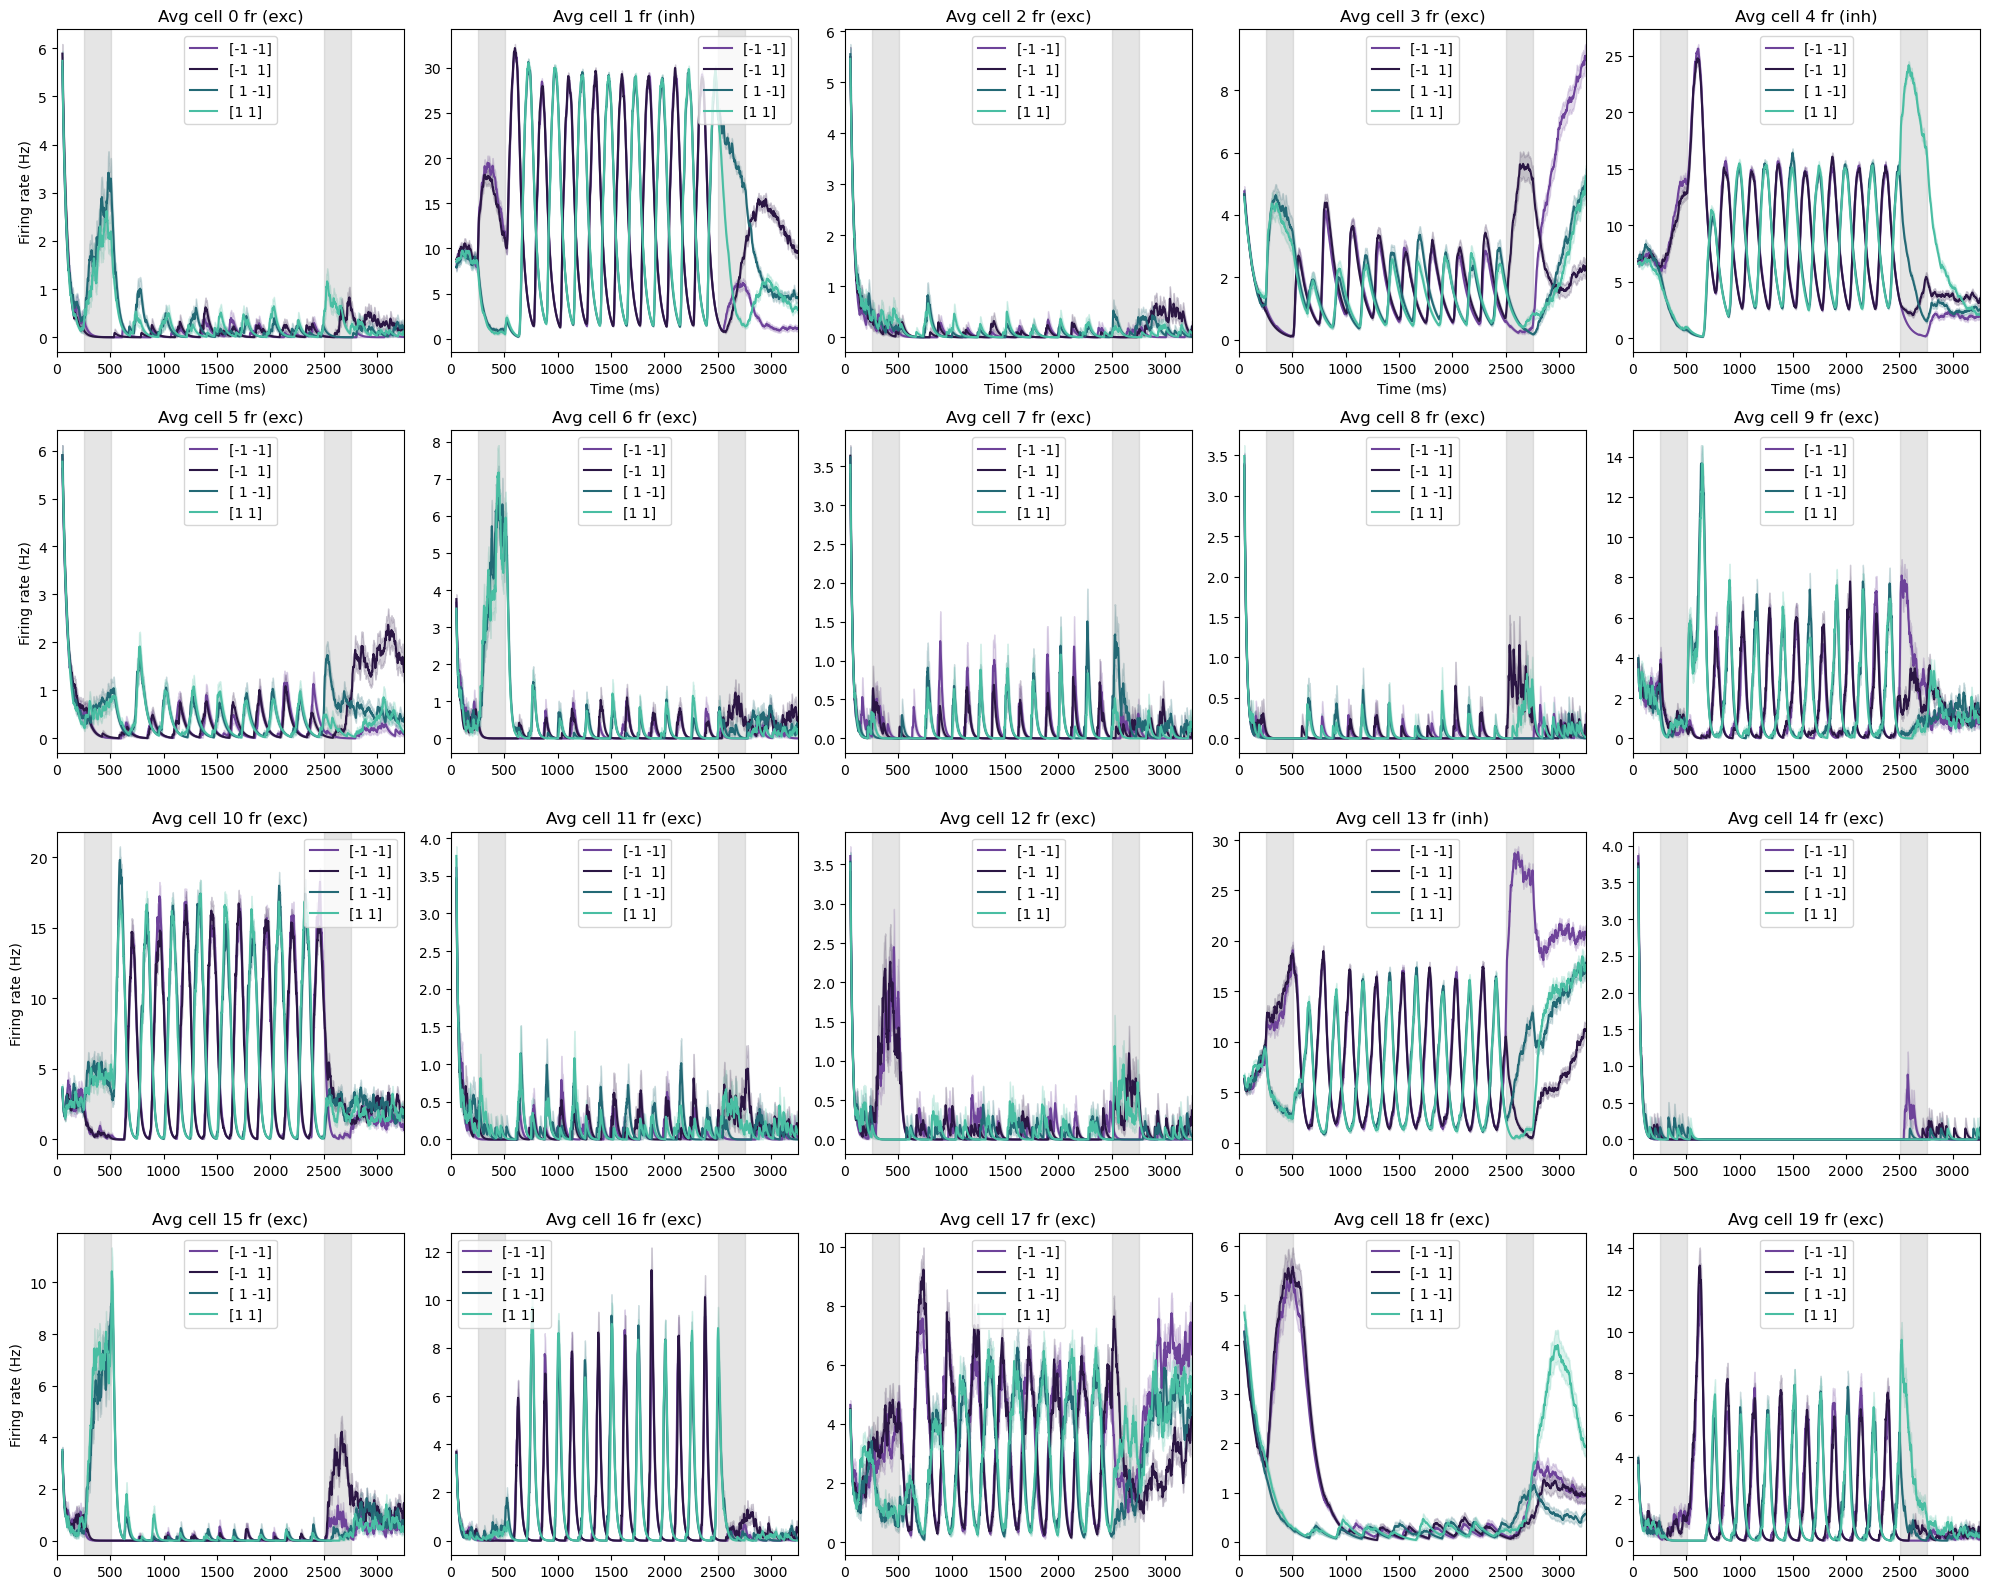

In [6]:
# let's take a look some neurons
importlib.reload(sn)

fig, axs = plt.subplots(4,5, figsize=(20,16))
axs = axs.flatten()
for n_neuron in range(20):
    sn.plot_neuron_rates(model_name, n_neuron, condn_phrase, condn_num, rates_data = rates_data, 
                         cut_off=50, baseline=False, ax=axs[n_neuron],
                         all_models_dir=all_models_dir)
    # axs[n_neuron].set_title(f'Neuron {n_neuron}')

# remove axis labels besides the first row and first column
for i in range(4):
    for j in range(5):
        if i > 0:
            axs[i*5 + j].set_xlabel('')
        if j > 0:
            axs[i*5 + j].set_ylabel('')
        
plt.tight_layout()
plt.show()

### LFP

In [11]:
lfp_data.shape # time x neurons x trials

(3255, 200, 1000)

In [17]:
(np.mean(lfp_data, axis=1).T).shape

(1000, 3255)

In [18]:
power.shape

(1000, 40, 3255)

In [20]:
print(int(10/200*fs), int(50/200*fs))

50 250


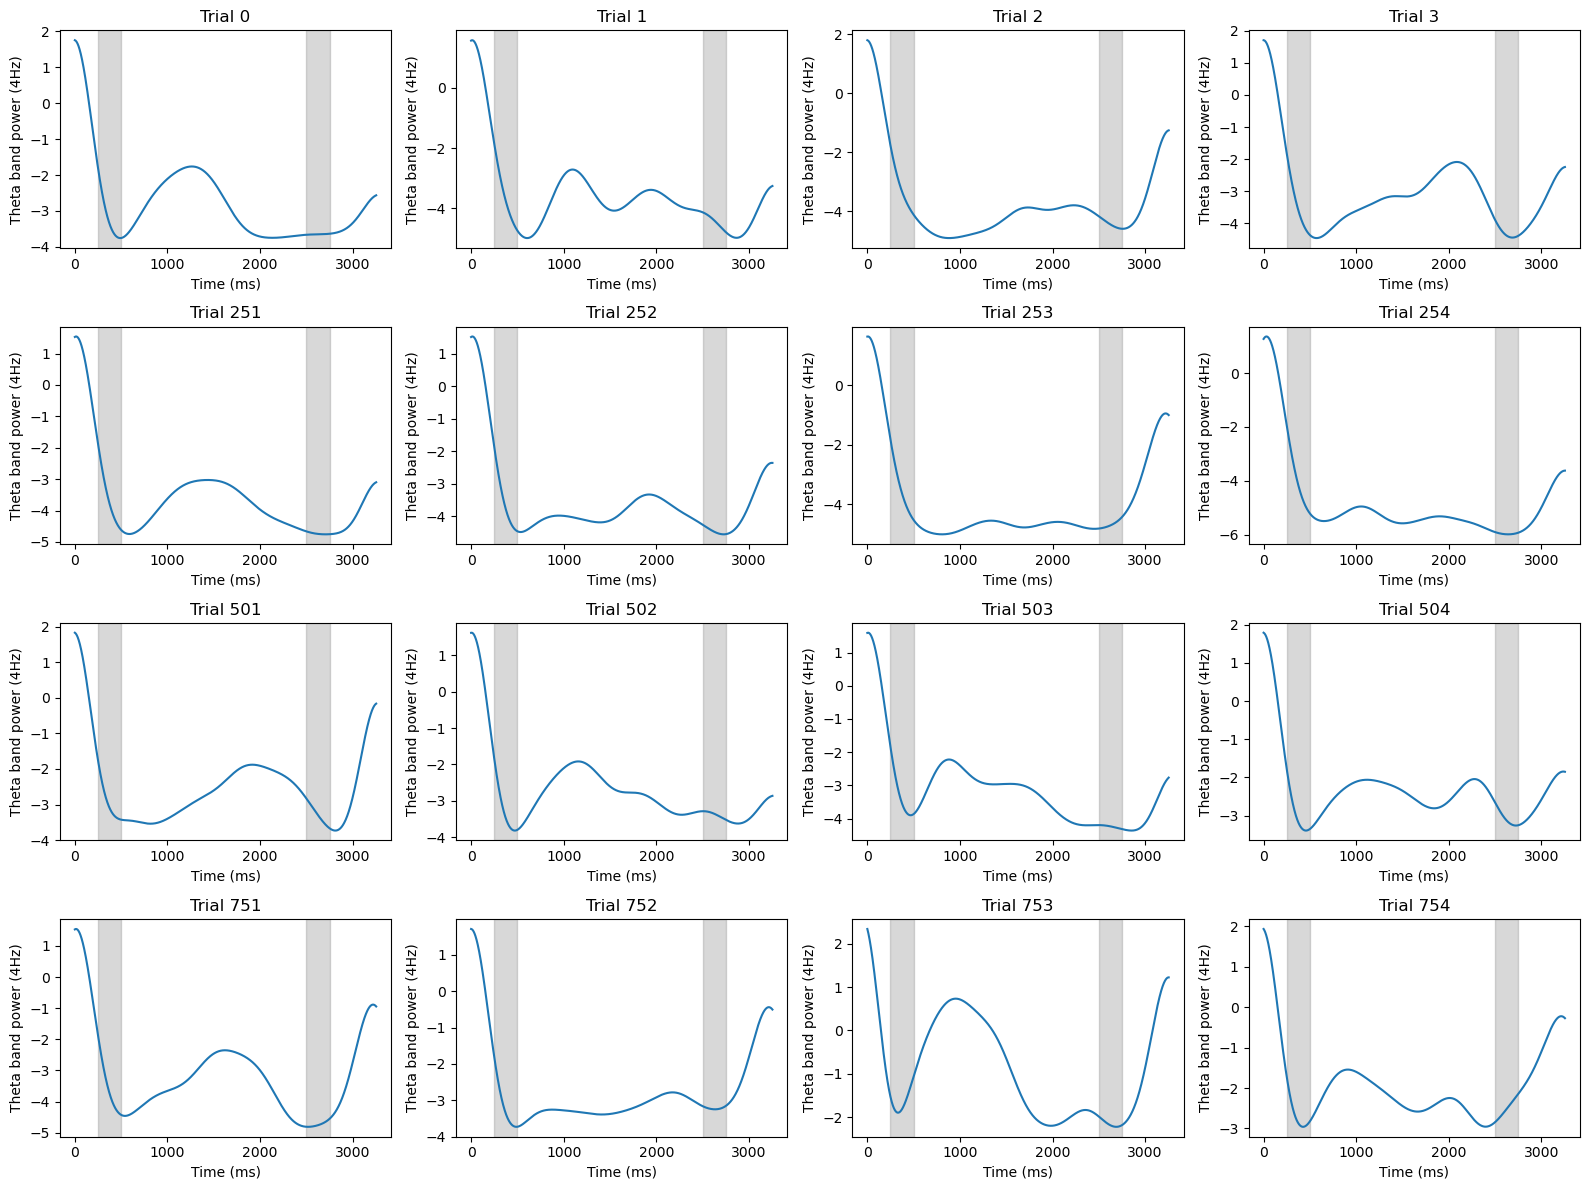

In [ ]:
import lfp_utils as lu

fs = 1000

# plot LFP for a few trials
fig, axs = plt.subplots(4,4, figsize=(16,12))
axs = axs.flatten()

power, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs) # average across neurons. power is (n_trials, n_freqs, n_times)
bandpower, band_sem = lu.calc_band_power(power, freqs, [4], baseline_times=[int(10/200*fs), int(50/200*fs)])

for i, trial_id in enumerate(trial_ids):
    axs[i].plot(bandpower[i,:])
    # axs[i].fill_between(np.arange(bandpower.shape[1]), bandpower[i,:] - band_sem[i,:], bandpower[i,:] + band_sem[i,:], alpha=0.3)
    axs[i].axvspan(250, 500, color='gray', alpha=0.3)
    axs[i].axvspan(2500, 2750, color='gray', alpha=0.3)
    axs[i].set_title(f'Trial {trial_id}')
    axs[i].set_xlabel('Time (ms)')
    axs[i].set_ylabel('Theta band power (4Hz)')
plt.tight_layout()
plt.show()

### tuning

In [16]:
# save some tuning

from scipy.io import savemat
import concurrent.futures
importlib.reload(sn)

delays = [50, 150]

def process_model_condn(args):
    model_name, condn_num, condn_phrase, all_models_dir = args
    tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    untuned_idx = np.where(np.isnan(tuning))[0]

    save_path = os.path.join(all_models_dir, model_name, f'tuning_{condn_phrase}_{condn_num}.mat')
    savemat(save_path, {'tuning': tuning, 'untuned_idx': untuned_idx})

    return f'Saved tuning for {model_name} at {condn_phrase} {condn_num} with {len(untuned_idx)} untuned neurons.'

# Prepare tasks
tasks = []
for model_name in model_dirs:
    for condn_num in delays:
        tasks.append((model_name, condn_num, condn_phrase, all_models_dir))

# Run in parallel
with concurrent.futures.ProcessPoolExecutor() as executor:
    for result in executor.map(process_model_condn, tasks):
        print(result)


Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_192759 at delay 50 with 14 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_192759 at delay 150 with 14 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_191905 at delay 50 with 28 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_191905 at delay 150 with 29 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_194403 at delay 50 with 17 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_194403 at delay 150 with 18 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_195544 at delay 50 with 17 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_195544 at delay 150 with 18 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_185857 at delay 50 with

In [17]:
n_untuned = np.zeros((len(model_dirs), len(delays)))
for i, model_name in enumerate(model_dirs):
    for j, condn_num in enumerate(delays):
        tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
        n_untuned[i, j] = np.sum(np.isnan(tuning))
    print(f'Number of untuned neurons for {model_name}: {n_untuned[i, :]}')


Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_192759: [14. 14.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_191905: [28. 29.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_194403: [17. 18.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_195544: [17. 18.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_185857: [17. 20.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_184512: [34. 34.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_193702: [18. 18.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_162650: [39. 40.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_194942: [29. 30.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_182548: [29. 22.]


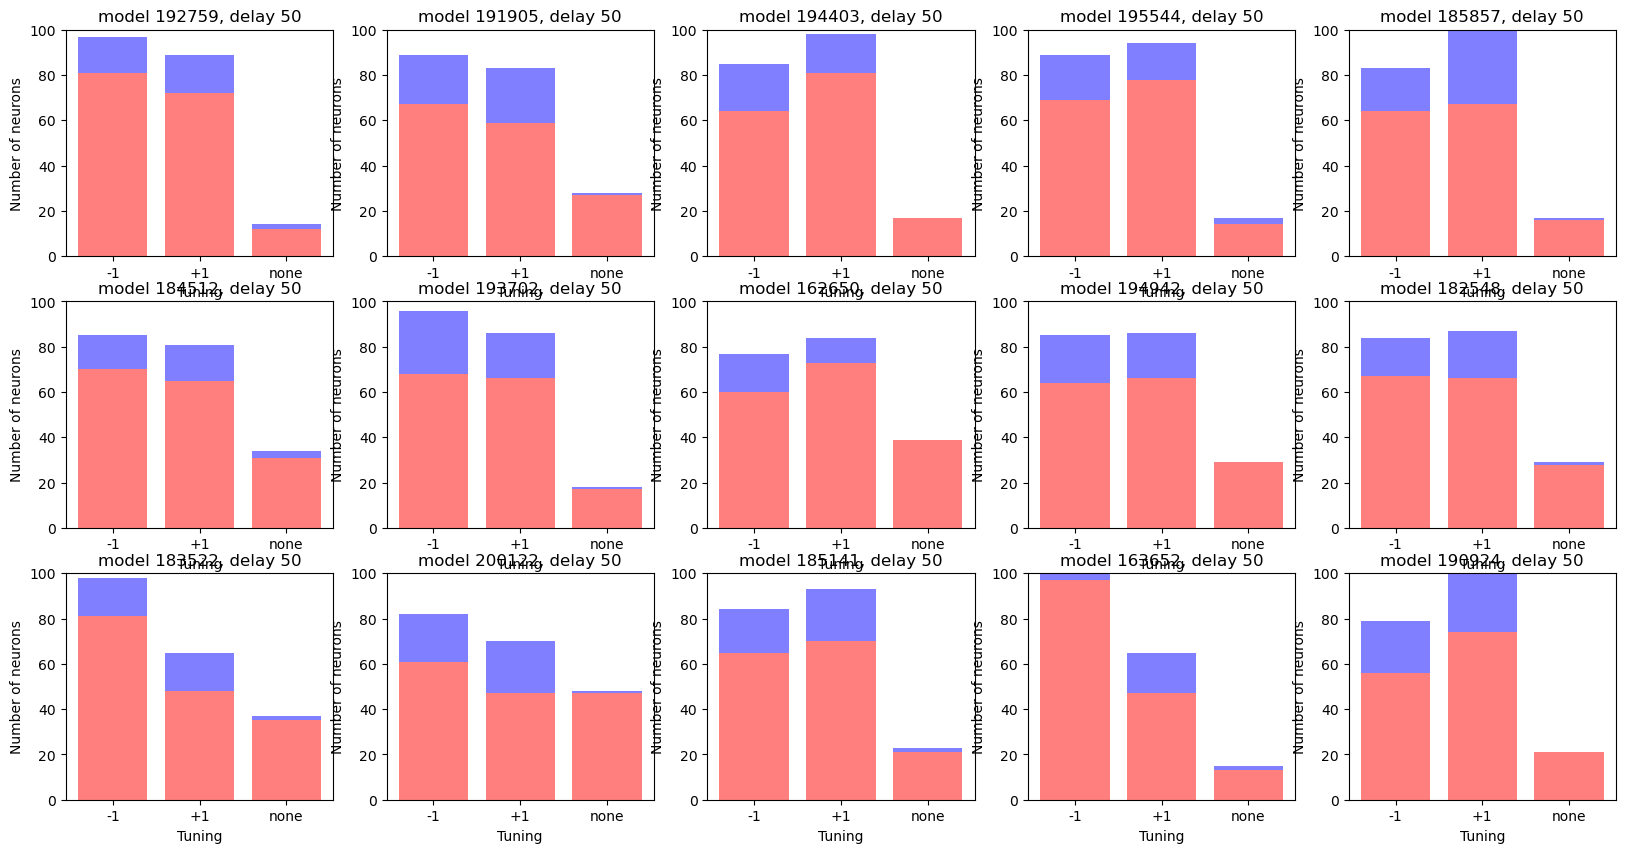

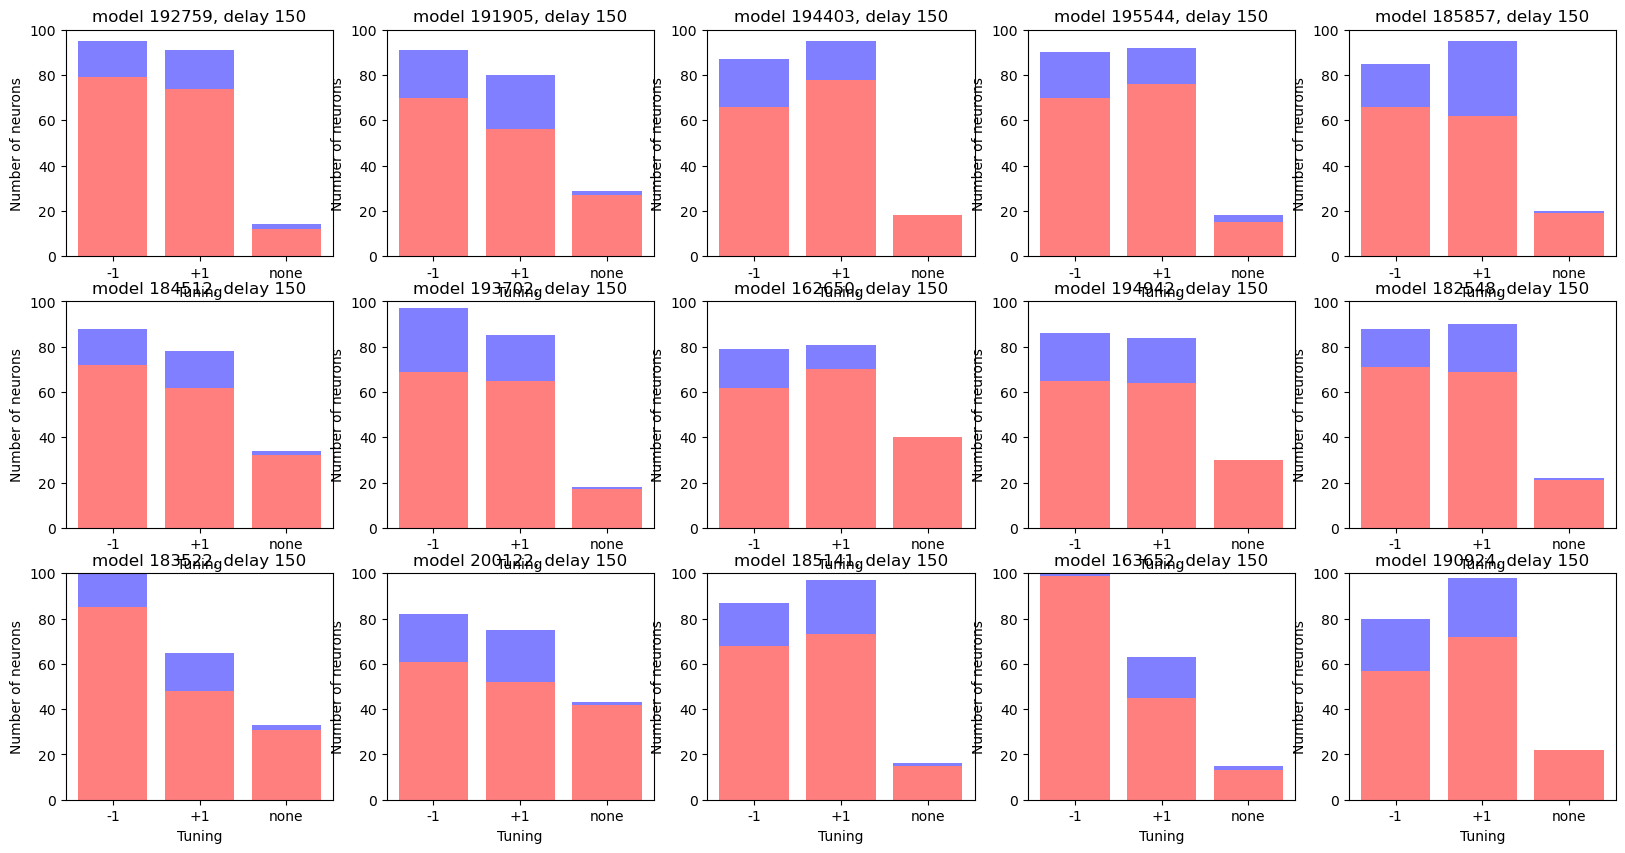

In [24]:
# plot tuning

for j, condn_num in enumerate(delays):
    fig, axs = plt.subplots(3, 5, figsize=(20, 10))
    axs = axs.flatten()
    for i, model_name in enumerate(model_dirs):
        tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
        exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase=condn_phrase, condn_num=condn_num, all_models_dir=all_models_dir)
        sn.plot_stim1_tuning(tuning, exc_ind=exc_ind, ax=axs[i], title=f'model {model_name[-6:]}, {condn_phrase} {condn_num}')
plt.show()

### trajectories

#### one example model

In [25]:
# load some more data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=150,
                                             all_models_dir=all_models_dir)
_,_,rates_data = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=150, load_rates=True,
                                     all_models_dir=all_models_dir)
tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase=condn_phrase, condn_num=150,
                                      all_models_dir=all_models_dir)
exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase=condn_phrase, condn_num=150,
                                          all_models_dir=all_models_dir)

PCA explained variance: [0.55547063 0.15710949 0.09506485], total: 0.8076449702253249
PCA explained variance: [0.38706345 0.16896606 0.13117784], total: 0.6872073477227039
PCA explained variance: [0.63673614 0.16370659 0.07675801], total: 0.8772007421610428


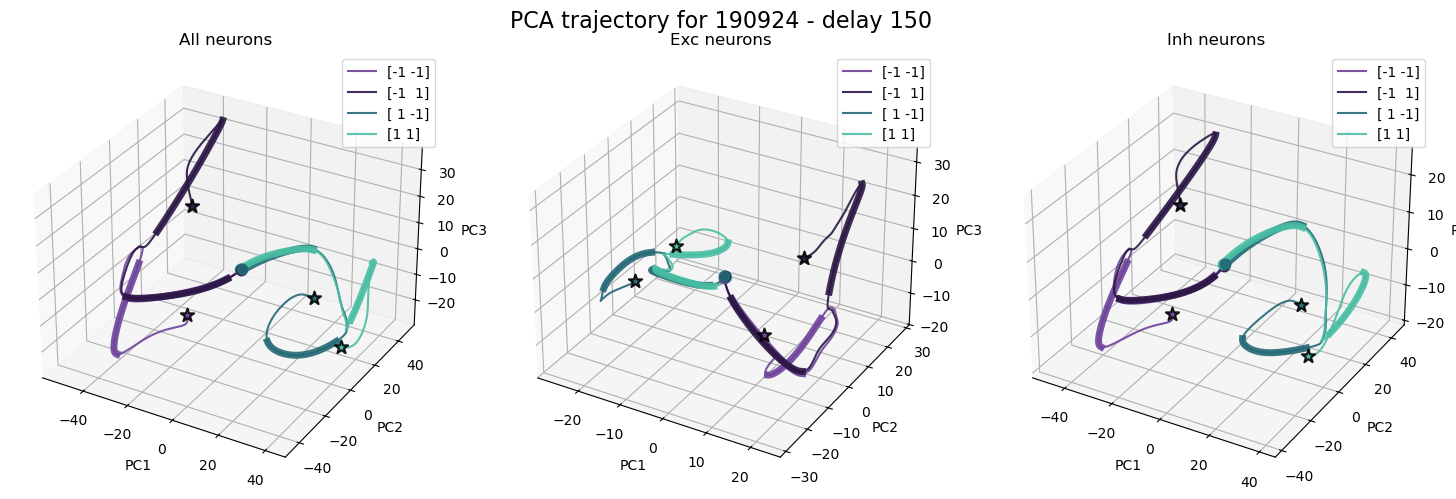

In [26]:
import population_utils as pu
importlib.reload(pu)

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
_, pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons',
                   all_models_dir=all_models_dir)
_, pca_exc = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150,
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons',
                   all_models_dir=all_models_dir)
_, pca_inh = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150,
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {150}', fontsize=16)
plt.tight_layout()
plt.show()

Accuracy for 190924: 0.985
PCA explained variance: [0.55547063 0.15710949 0.09506485], total: 0.8076449702253249
PCA explained variance: [0.55547063 0.15710949 0.09506485], total: 0.8076449702253249


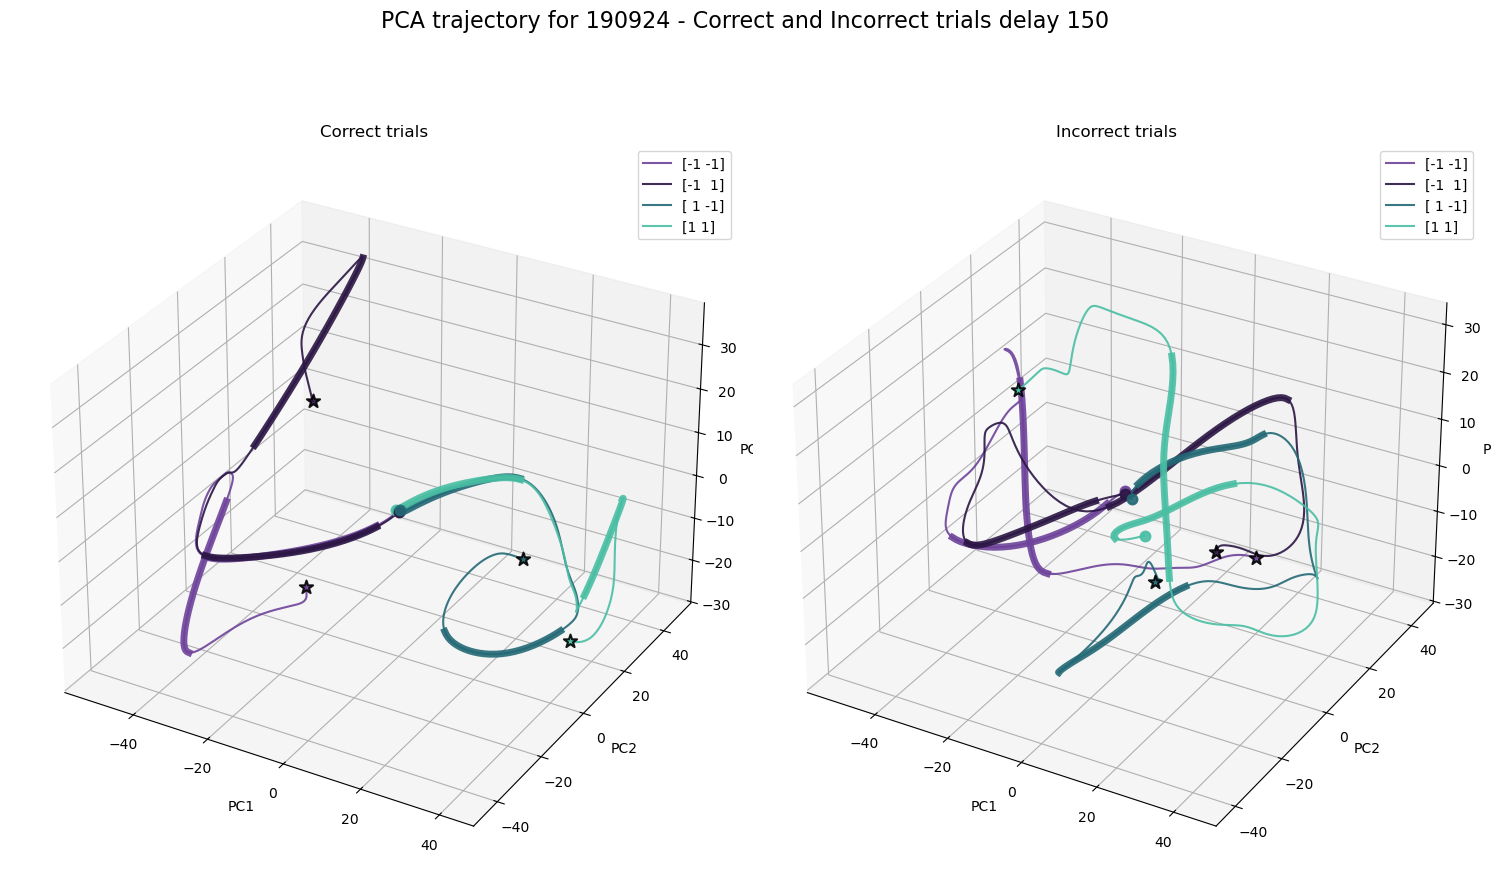

In [ ]:
# plot correct and incorrect next to each other

print(f'Accuracy for {model_name[-6:]}: {trial_perfs.mean()}')

fig = plt.figure(figsize=(15, 10))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax1, title='Correct trials',
                   all_models_dir=all_models_dir)
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax2, title='Incorrect trials',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Correct and Incorrect trials {condn_phrase} {150}', fontsize=16)
plt.tight_layout()
plt.show()##

#### another example model

In [38]:
# choose a model to visualize for now
model_name = model_dirs[4]
model_dir = os.path.join(all_models_dir, model_name)

# print accuracy on delay=150
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=150,
                                             all_models_dir=all_models_dir)
print(f'Accuracy for {model_name[-6:]}: {trial_perfs.mean()}')

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

Accuracy for 185857: 0.716
['/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_185857/neuraldata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_185857/bhvdata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_185857/timingdata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_185857/lowfr_delay150_2.npy']


In [39]:
# load some more data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=150,
                                             all_models_dir=all_models_dir)
_,_,rates_data = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=150, load_rates=True,
                                     all_models_dir=all_models_dir)
tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase=condn_phrase, condn_num=150,
                                      all_models_dir=all_models_dir)
exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase=condn_phrase, condn_num=150,
                                          all_models_dir=all_models_dir)

PCA explained variance: [0.49255844 0.18460345 0.08394361], total: 0.7611054973400936
PCA explained variance: [0.38607863 0.19192313 0.10461084], total: 0.6826126054107199
PCA explained variance: [0.56677382 0.18073702 0.08678694], total: 0.8342977853022342


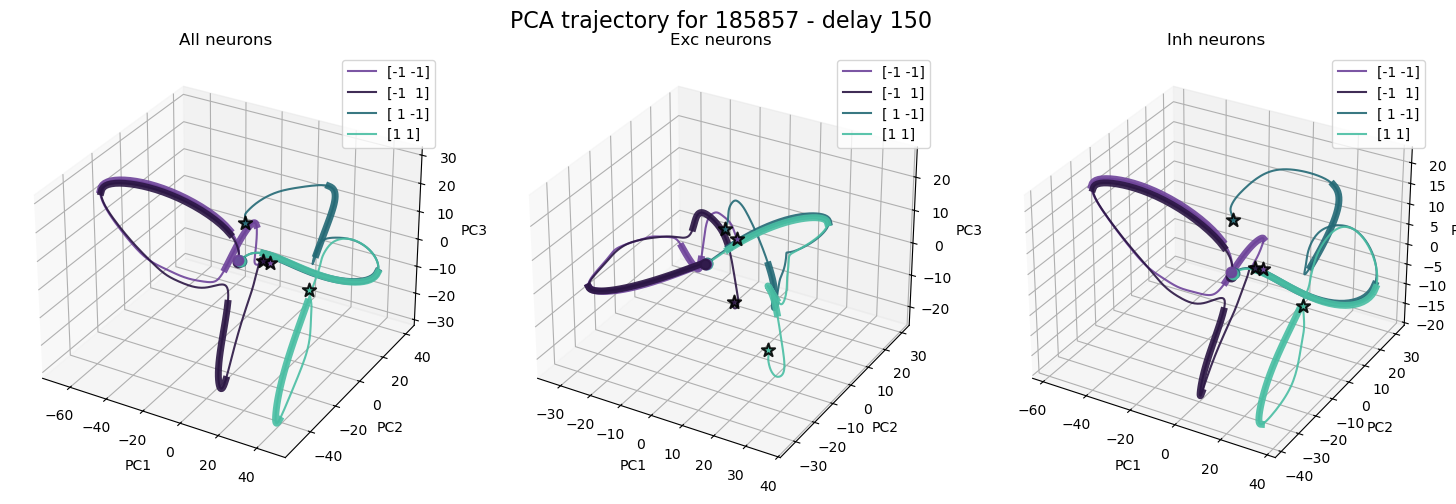

In [40]:
import population_utils as pu
importlib.reload(pu)

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
_, pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons',
                   all_models_dir=all_models_dir)
_, pca_exc = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150,
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons',
                   all_models_dir=all_models_dir)
_, pca_inh = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150,
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {150}', fontsize=16)
plt.tight_layout()
plt.show()

In [41]:
rates_corr = rates_data[:,:,trial_perfs == 1]
rates_incorr = rates_data[:,:,trial_perfs == 0]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

Accuracy for 185857: 0.716
PCA explained variance: [0.49255844 0.18460345 0.08394361], total: 0.7611054973400936
PCA explained variance: [0.49255844 0.18460345 0.08394361], total: 0.7611054973400936


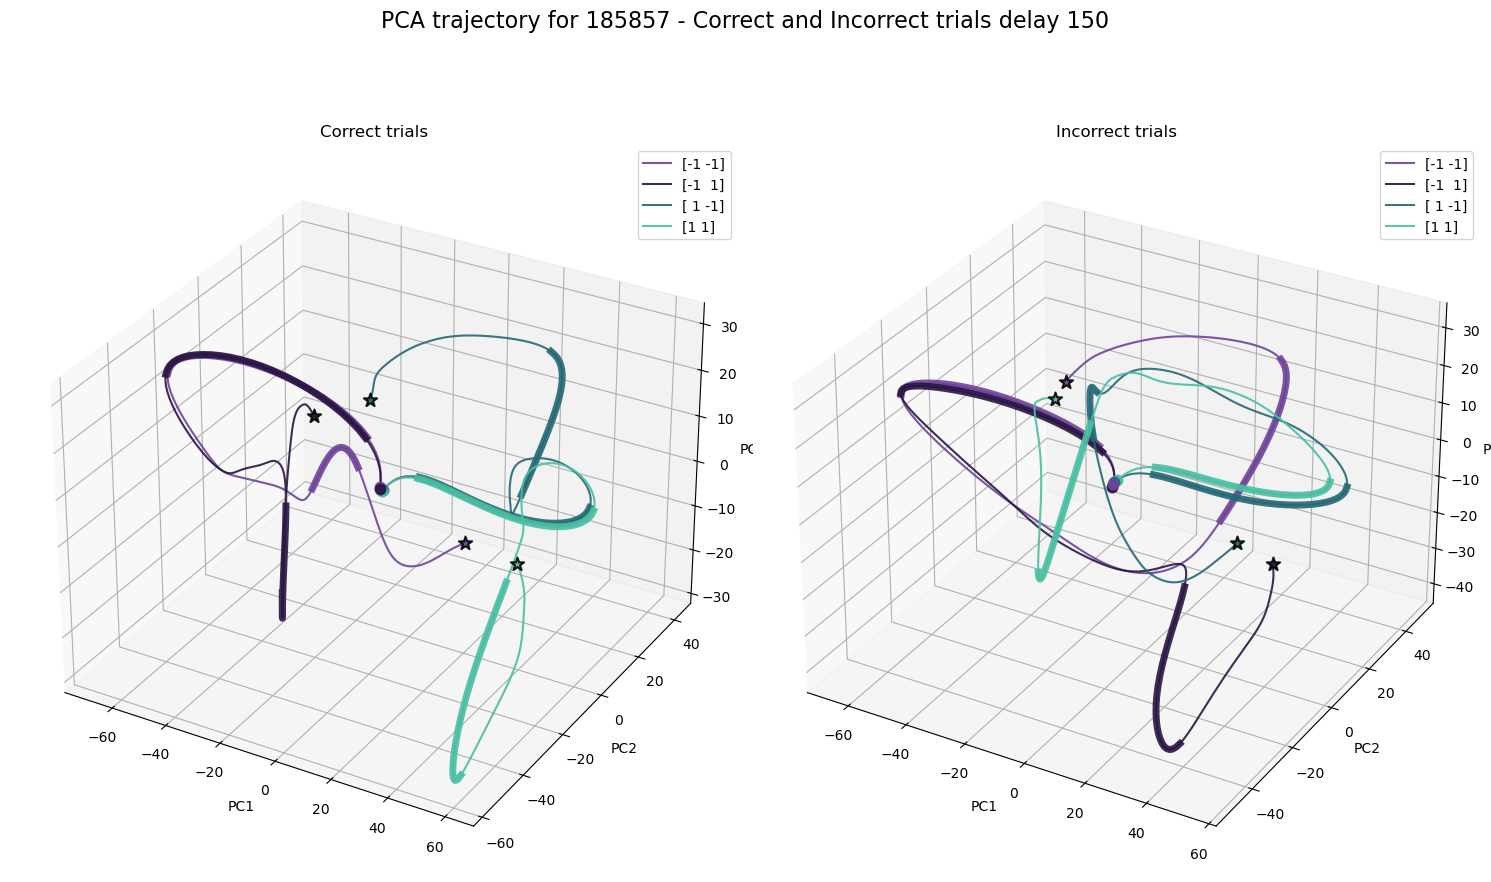

In [42]:
# plot correct and incorrect next to each other

print(f'Accuracy for {model_name[-6:]}: {trial_perfs.mean()}')

fig = plt.figure(figsize=(15, 10))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax1, title='Correct trials',
                   all_models_dir=all_models_dir)
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax2, title='Incorrect trials',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Correct and Incorrect trials {condn_phrase} {150}', fontsize=16)
plt.tight_layout()
plt.show()##

Accuracy for 185857: 0.716
PCA explained variance: [0.49255844 0.18460345 0.08394361], total: 0.7611054973400936
PCA explained variance: [0.49255844 0.18460345 0.08394361], total: 0.7611054973400936


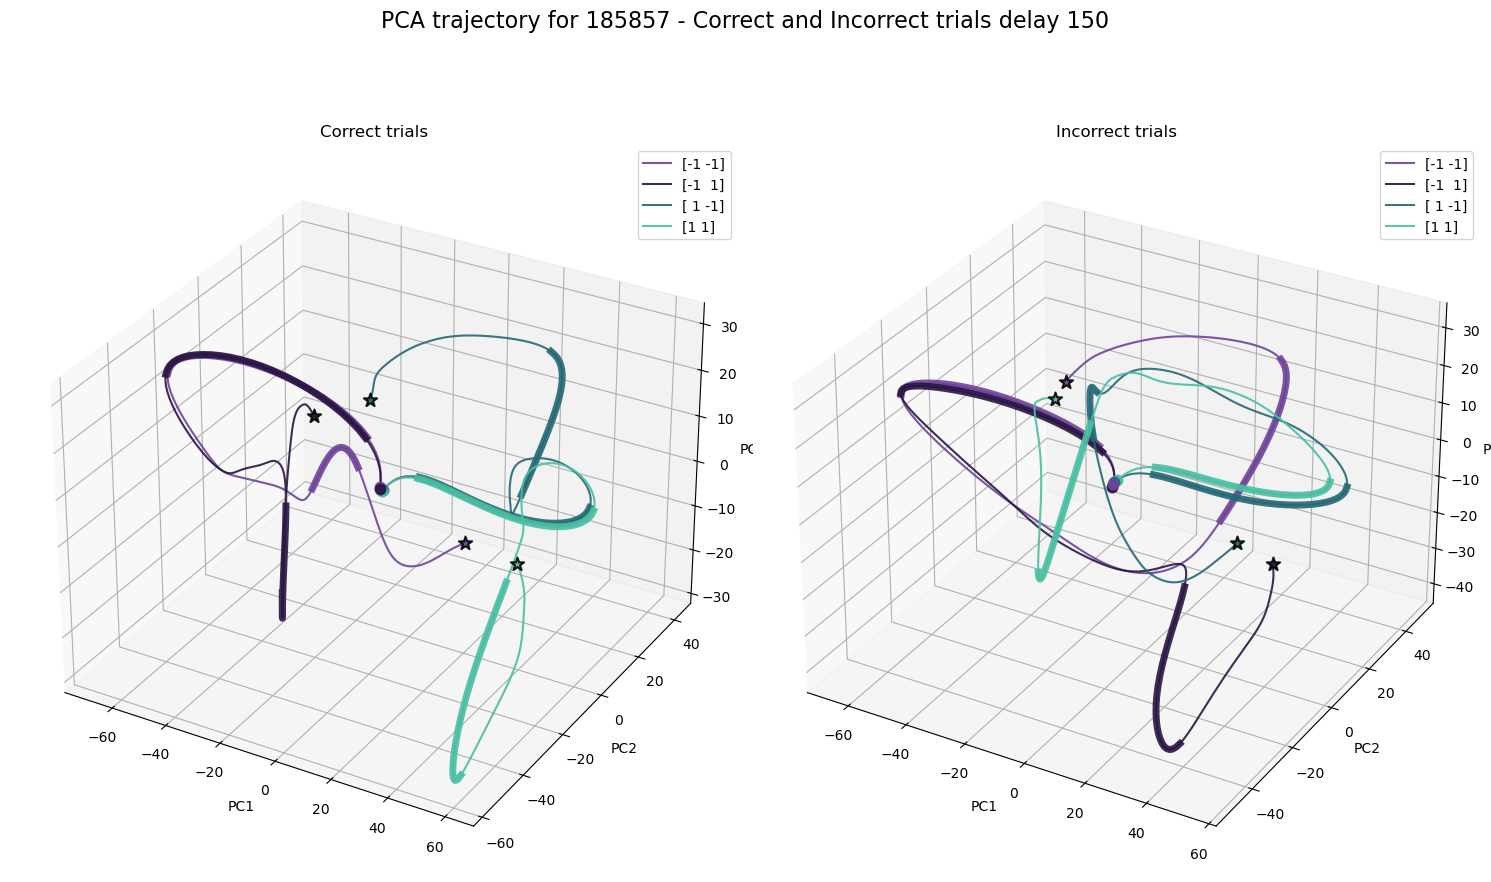

In [ ]:
# plot correct and incorrect next to each other
importlib.reload(pu)
print(f'Accuracy for {model_name[-6:]}: {trial_perfs.mean()}')

fig = plt.figure(figsize=(15, 10))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_corr, trial_labels=trials_labels_corr, cut_off=50, ax=ax1, title='Correct trials',
                   all_models_dir=all_models_dir)
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=150, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_incorr, trial_labels=trials_labels_incorr, cut_off=50, ax=ax2, title='Incorrect trials',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Correct and Incorrect trials {condn_phrase} {150}', fontsize=16)
plt.tight_layout()
plt.show()